# Exploratory Data Analysis — Industrial Defect Detection

This notebook explores the dataset and validates the segmentation
pipeline used in `src/`. It produces the visualizations referenced
in the project README.

**Contents:**
1. Setup — import project modules
2. Class samples — one example image + ground-truth bbox + mask per class
3. Segmentation test — compare predicted vs ground-truth bounding boxes
4. Feature separability — how well the 10 extracted features distinguish classes

## 1. Setup

Import project modules from `src/` so we reuse the exact same
segmentation and config logic used in training and prediction —
no code duplication.

In [2]:

import sys
import os

sys.path.append(os.path.abspath(".."))

import cv2
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.config import TRAIN_DIR, VAL_DIR, OUTPUT_DIR, CLASSES, imread_unicode, imread_unicode_gray
from src.segmentation import segment_defect

print("Setup OK")
print("TRAIN_DIR:", TRAIN_DIR)

Setup OK
TRAIN_DIR: D:\Software\Bootcamps\Teknokent İleri Bilişim Teknolojileri Kurs\Hafta-8-goruntu-isleme\gun-5-uygulama\Proje\train


## 2. Class Samples

One example per class, showing the original image with its
ground-truth bounding box (green) and the corresponding defect mask.
This illustrates the visual signature of each defect type:

- **scratch** — thin elongated line
- **stain** — dark, filled blob inside the product
- **missing_part** — bright circular gap at the product edge
- **deformation** — small shape distortion at the product edge

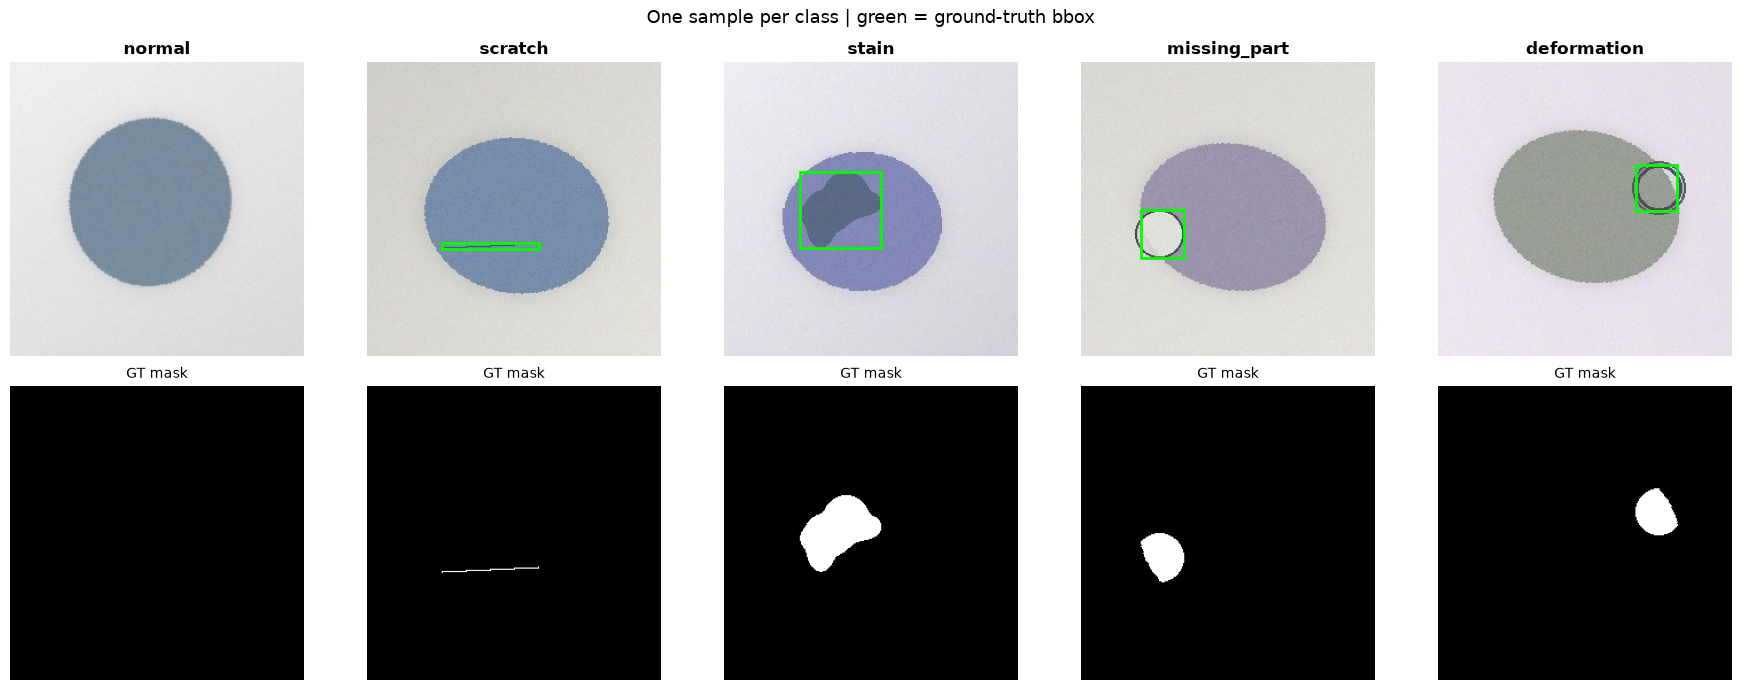

Saved -> D:\Software\Bootcamps\Teknokent İleri Bilişim Teknolojileri Kurs\Hafta-8-goruntu-isleme\gun-5-uygulama\Proje\defect_detection\outputs/class_samples.png


In [3]:
# Load train labels
with open(f"{TRAIN_DIR}/labels.csv", newline="", encoding="utf-8") as f:
    import csv
    train_rows = list(csv.DictReader(f))

# Plot one example per class: image + GT bbox (top row), mask (bottom row)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ci, cname in enumerate(CLASSES):
    sample = next(r for r in train_rows if r["class_name"] == cname)

    img = cv2.cvtColor(
        imread_unicode(f"{TRAIN_DIR}/images/{sample['image_id']}"),
        cv2.COLOR_BGR2RGB)
    mask = imread_unicode_gray(f"{TRAIN_DIR}/masks/{sample['mask_file']}") \
    if sample.get("mask_file") else np.zeros_like(img[:, :, 0])

    # Top row: image with GT bounding box
    axes[0, ci].imshow(img)
    x1, y1, x2, y2 = (int(sample[k]) for k in ["x1", "y1", "x2", "y2"])
    if (x1, y1, x2, y2) != (0, 0, 0, 0):
        axes[0, ci].add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"))
    axes[0, ci].set_title(cname, fontsize=12, fontweight="bold")
    axes[0, ci].axis("off")

    # Bottom row: ground-truth mask
    axes[1, ci].imshow(mask, cmap="gray")
    axes[1, ci].set_title("GT mask", fontsize=10)
    axes[1, ci].axis("off")

plt.suptitle("One sample per class | green = ground-truth bbox", fontsize=13)
plt.tight_layout()

# Save for README
save_path = f"{OUTPUT_DIR}/class_samples.png"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")